DOWNLOADING WORLD BANK PINK SHEET
Download successful: 586,735 bytes

Available sheets:
['Mismatch Details', 'Monthly Prices', 'Monthly Indices', 'Description', 'Index Weights']

Monthly Prices shape: (806, 72)

Searching for Gold column...
Gold column detected at column index: 69
Gold header row detected: 4
Gold header value: Gold

Searching for monthly date column...
Date column detected at column index: 0
Monthly date matches detected: 800

Extracting monthly Gold prices...

GOLD DATA SUCCESSFULLY EXTRACTED
Observations: 800
Date range: 1960-01-01 to 2026-08-01
Missing prices: 0
Duplicate dates: 0
Dates sorted: True

First 5 observations:
        date  price_usd
0 1960-01-01       35.0
1 1960-02-01       35.0
2 1960-03-01       35.0
3 1960-04-01       35.0
4 1960-05-01       35.0

Last 5 observations:
          date  price_usd
795 2026-04-01     4721.0
796 2026-05-01     4587.0
797 2026-06-01     4228.0
798 2026-07-01     4073.0
799 2026-08-01     4411.0

Feature engineering complet

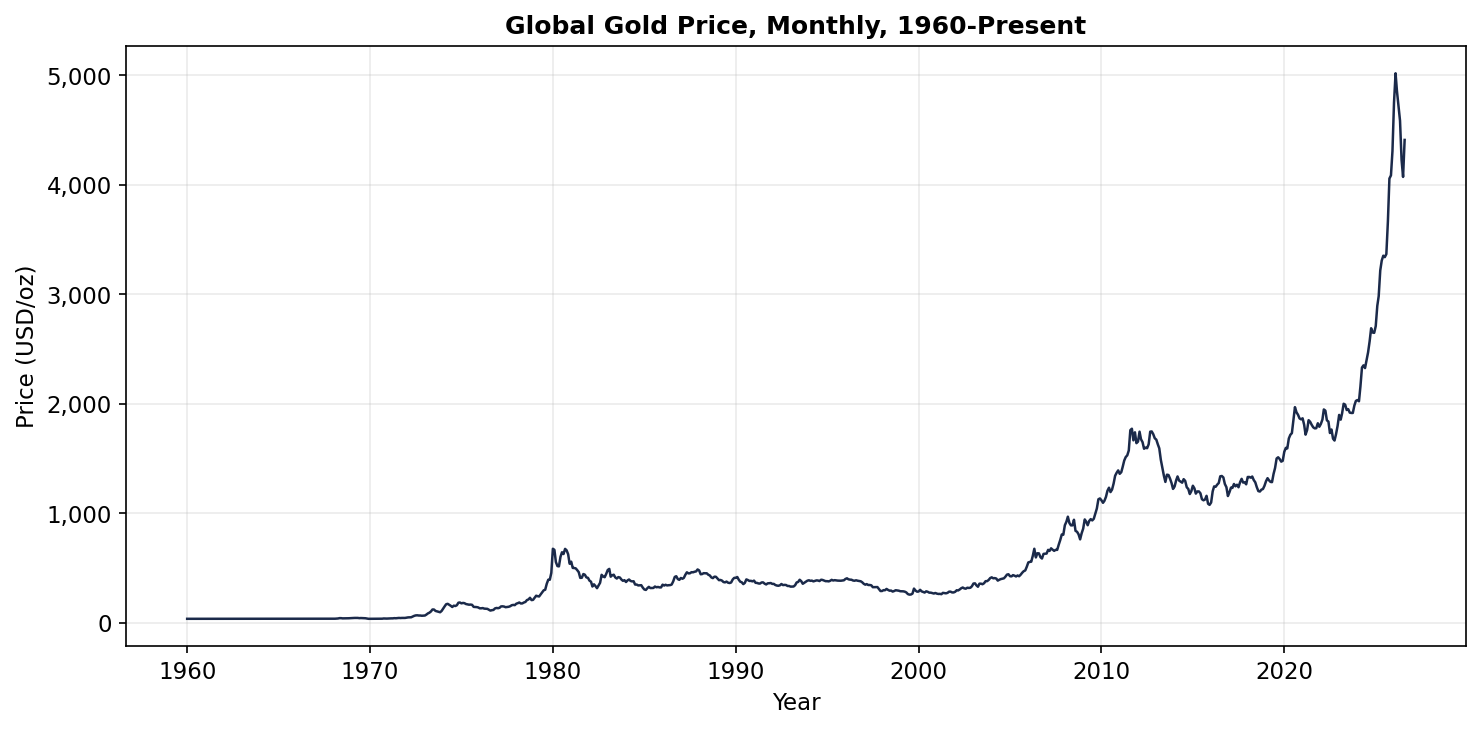

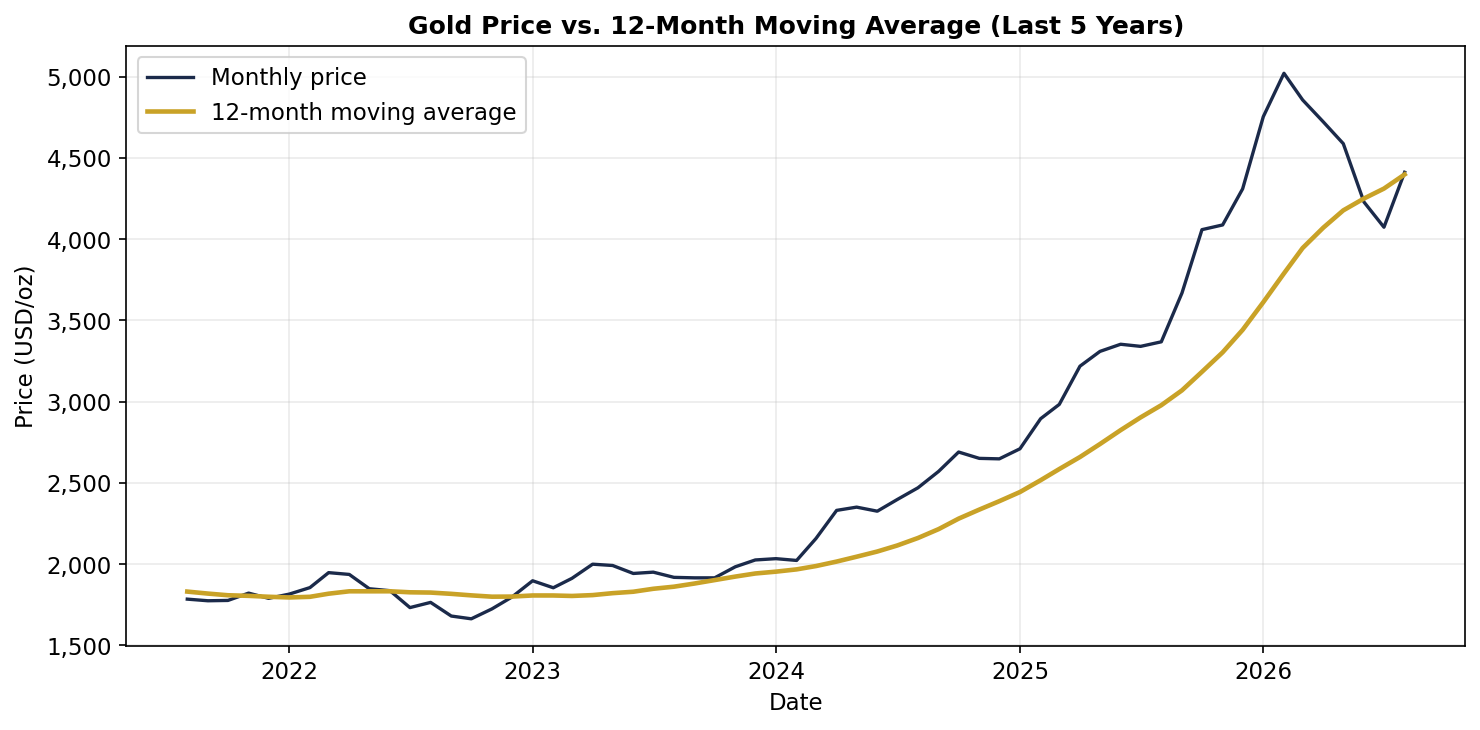

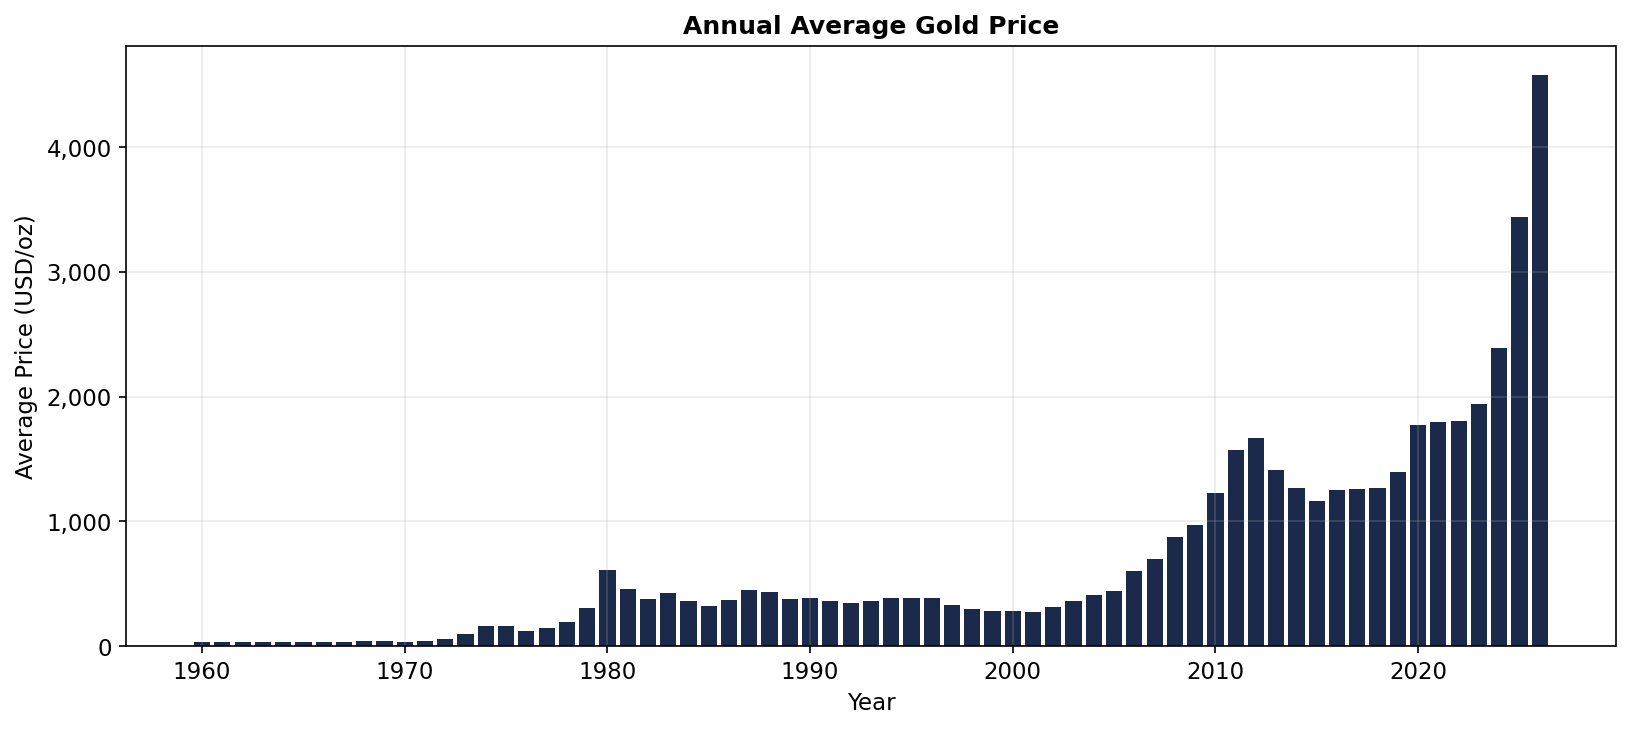

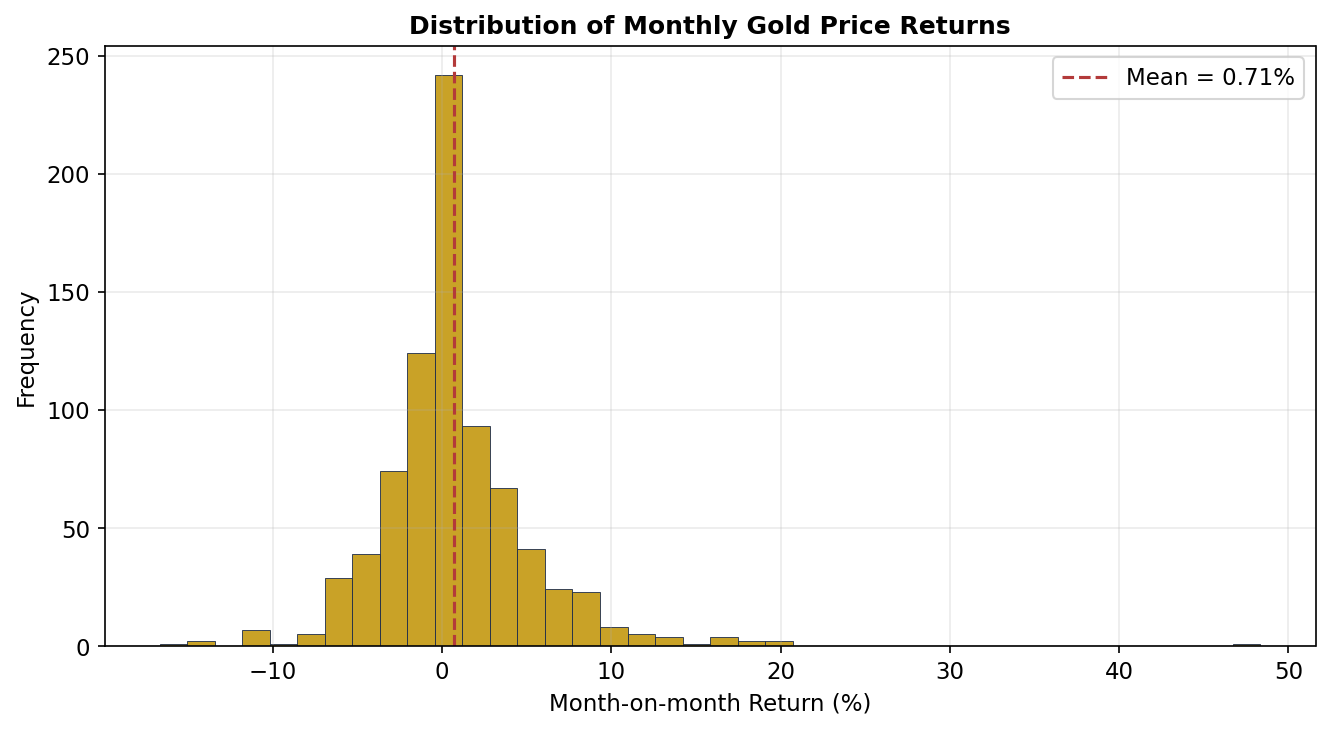

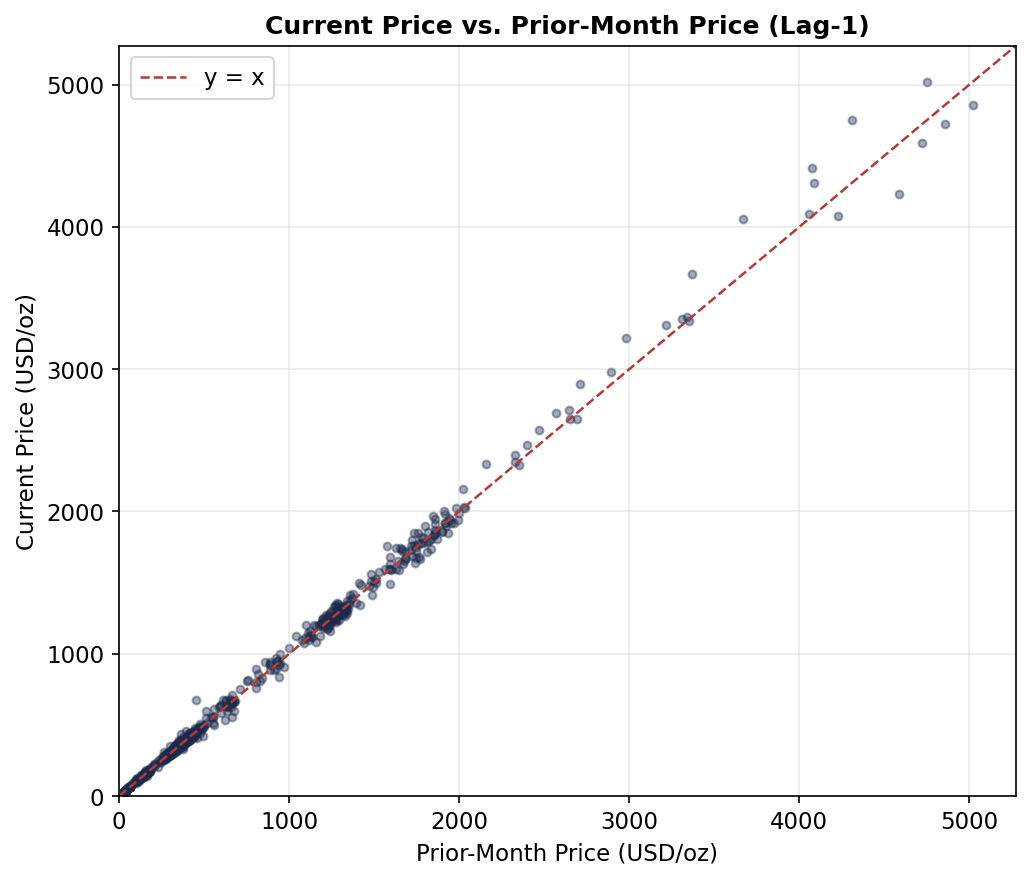

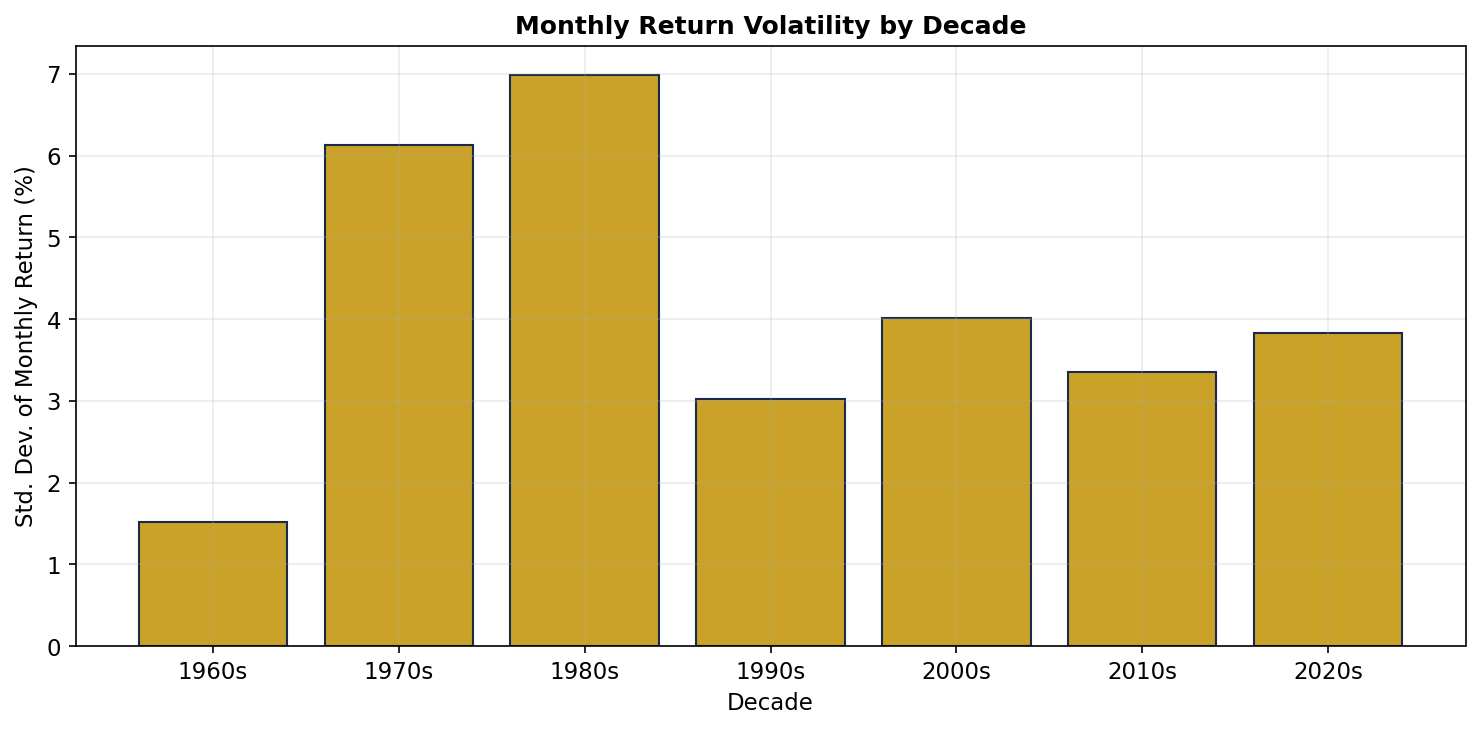

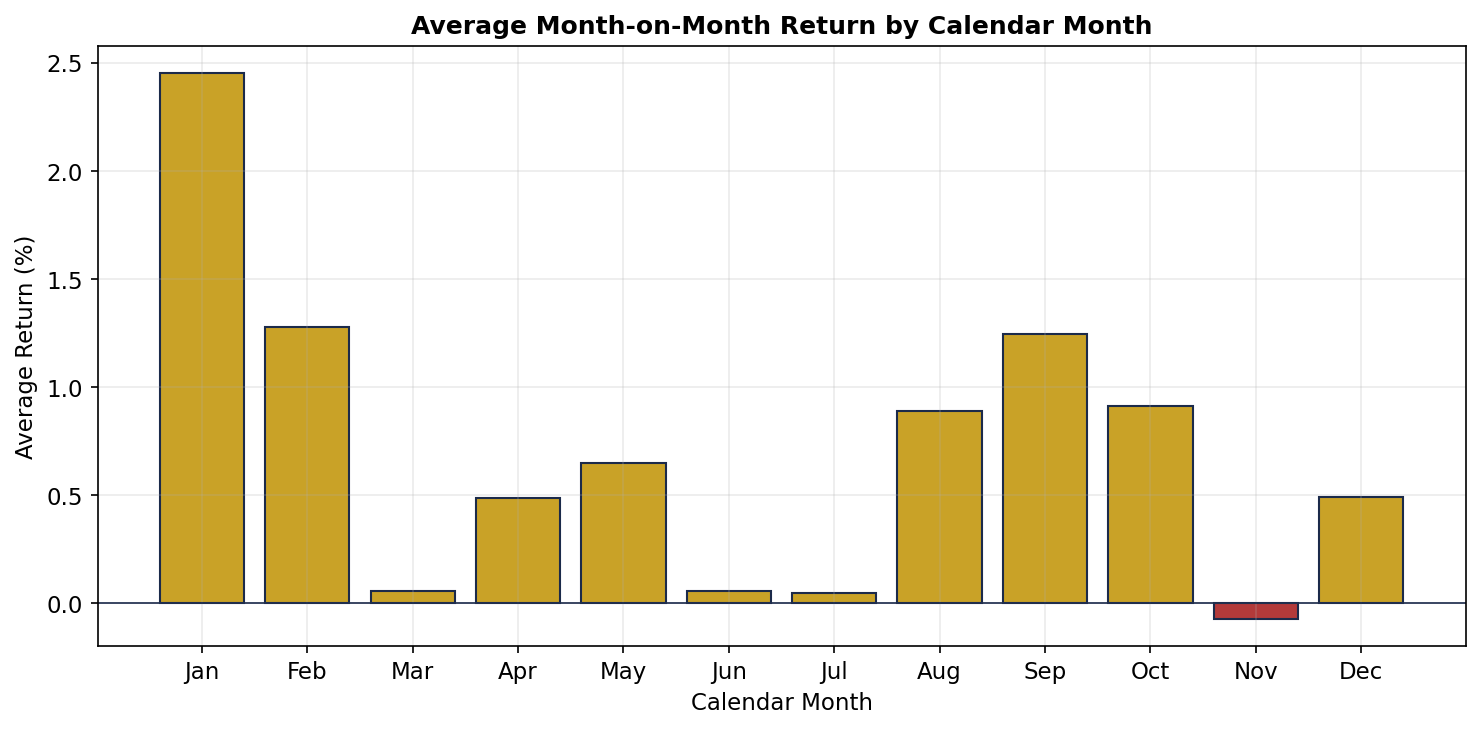


PREDICTIVE ANALYTICS
Usable modelling rows: 787

Target variable: target_next_month

Predictors:
  - lag_1
  - lag_2
  - lag_3
  - ma_3
  - ma_12
  - rolling_vol_12
  - month_sin
  - month_cos

Training period: 1961-01-01 to 2013-05-01 (n=629)
Testing period: 2013-06-01 to 2026-07-01 (n=158)

MODEL COMPARISON
                         R2      RMSE       MAE
Naive (random-walk)  0.9892   92.6655   57.1519
Linear Regression    0.9907   85.7189   54.0056
Ridge Regression     0.9904   87.1729   54.7429
Random Forest        0.0078  886.5593  467.4052

Best model by RMSE: Linear Regression
Best RMSE: 85.72


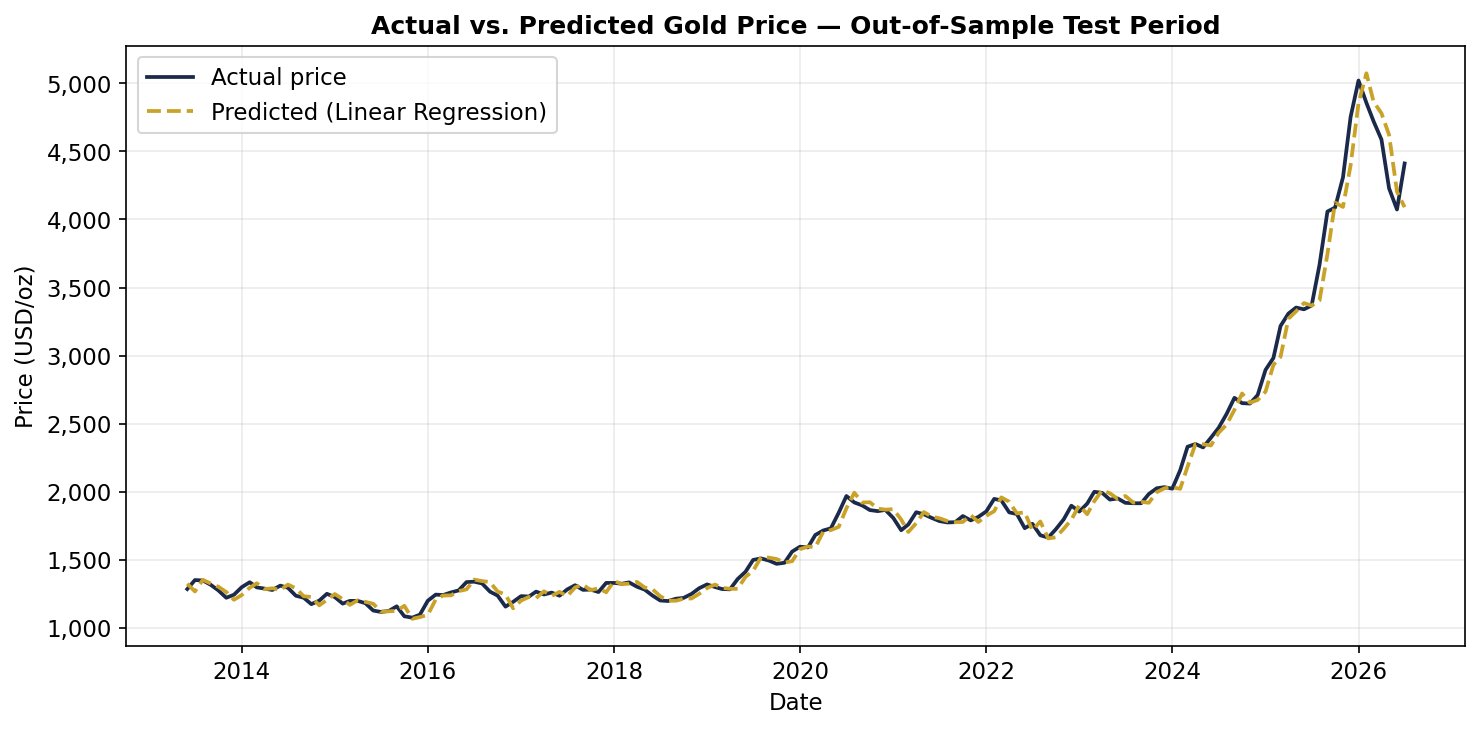


ONE-MONTH-AHEAD FORECAST
Model used: Linear Regression
Latest available date: 2026-08-01
Latest actual price: USD 4,411.00/oz
Forecast month: September 2026
Forecast price: USD 4,469.71/oz
Change vs latest actual: +1.33%
Approx. 80% uncertainty band: USD 4,359.99 to USD 4,579.43/oz

ANALYSIS COMPLETED SUCCESSFULLY
Dataset observations: 800
Dataset period: 1960-01-01 to 2026-08-01
Best model: Linear Regression
Forecast: USD 4,469.71/oz
Approx. uncertainty band: USD 4,359.99 to USD 4,579.43/oz
Charts saved in: /content/charts
Results saved in: /content/results
Data source: World Bank Commodity Markets (Pink Sheet)


In [1]:

import io
import re
import warnings
from pathlib import Path

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# -----------------------------
# Configuration
# -----------------------------
WORLD_BANK_URL = (
    "https://thedocs.worldbank.org/en/doc/"
    "74e8be41ceb20fa0da750cda2f6b9e4e-0050012026/"
    "related/CMO-Historical-Data-Monthly.xlsx"
)
CHARTS = Path("charts")
RESULTS = Path("results")
CHARTS.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)

NAVY = "#1B2A4A"
GOLD = "#C9A227"
RED = "#B33A3A"
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "figure.dpi": 150,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# -----------------------------
# 1. Download World Bank Pink Sheet
# -----------------------------
print("=" * 70)
print("DOWNLOADING WORLD BANK PINK SHEET")
print("=" * 70)
response = requests.get(WORLD_BANK_URL, timeout=60)
response.raise_for_status()
print(f"Download successful: {len(response.content):,} bytes")

# -----------------------------
# 2. Read Monthly Prices sheet
# -----------------------------
excel_bytes = io.BytesIO(response.content)
xls = pd.ExcelFile(excel_bytes)
print("\nAvailable sheets:")
print(xls.sheet_names)

if "Monthly Prices" not in xls.sheet_names:
    raise ValueError("Expected 'Monthly Prices' sheet was not found.")

excel_bytes.seek(0)
raw = pd.read_excel(excel_bytes, sheet_name="Monthly Prices", header=None)
print(f"\nMonthly Prices shape: {raw.shape}")

# -----------------------------
# 3. Detect Gold column and date column
# -----------------------------
print("\nSearching for Gold column...")
gold_col = None
header_row = None

for r in range(min(20, len(raw))):
    for c in raw.columns:
        value = raw.iloc[r, c]
        if pd.notna(value) and str(value).strip().lower() == "gold":
            gold_col, header_row = c, r
            break
    if gold_col is not None:
        break

if gold_col is None:
    for r in range(min(20, len(raw))):
        for c in raw.columns:
            value = raw.iloc[r, c]
            if pd.notna(value) and "gold" in str(value).strip().lower():
                gold_col, header_row = c, r
                break
        if gold_col is not None:
            break

if gold_col is None:
    raise ValueError("Could not locate the Gold column in the workbook.")

print(f"Gold column detected at column index: {gold_col}")
print(f"Gold header row detected: {header_row}")
print(f"Gold header value: {raw.iloc[header_row, gold_col]}")

month_pattern = re.compile(r"^\d{4}M\d{1,2}$")
date_col = None
best_match_count = 0

for c in raw.columns:
    count = 0
    for r in range(header_row + 1, len(raw)):
        value = raw.iloc[r, c]
        if pd.notna(value) and month_pattern.match(str(value).strip()):
            count += 1
    if count > best_match_count:
        best_match_count = count
        date_col = c

if date_col is None or best_match_count < 10:
    for c in raw.columns:
        for r in range(min(20, len(raw))):
            value = raw.iloc[r, c]
            if pd.notna(value) and str(value).strip().lower() in {"date", "period", "month"}:
                date_col = c
                break
        if date_col is not None:
            break

if date_col is None:
    raise ValueError("Could not identify the monthly date column.")

print("\nSearching for monthly date column...")
print(f"Date column detected at column index: {date_col}")
print(f"Monthly date matches detected: {best_match_count}")

# -----------------------------
# 4. Extract and clean Gold series
# -----------------------------
print("\nExtracting monthly Gold prices...")
records = []

for r in range(header_row + 1, len(raw)):
    raw_date = raw.iloc[r, date_col]
    raw_gold = raw.iloc[r, gold_col]
    if pd.isna(raw_date) or pd.isna(raw_gold):
        continue

    gold_value = pd.to_numeric(raw_gold, errors="coerce")
    if pd.isna(gold_value):
        continue

    date_value = None
    if isinstance(raw_date, pd.Timestamp):
        date_value = raw_date
    else:
        text = str(raw_date).strip()
        match = month_pattern.match(text)
        if match:
            year, month = int(text[:4]), int(text[5:])
            if 1 <= month <= 12:
                date_value = pd.Timestamp(year=year, month=month, day=1)
        else:
            parsed = pd.to_datetime(raw_date, errors="coerce")
            if not pd.isna(parsed):
                date_value = pd.Timestamp(parsed)

    if date_value is not None:
        records.append([date_value, float(gold_value)])

if not records:
    raise ValueError("No Gold observations could be extracted.")

df = pd.DataFrame(records, columns=["date", "price_usd"])
df["date"] = pd.to_datetime(df["date"])
df["price_usd"] = pd.to_numeric(df["price_usd"], errors="coerce")
df = (
    df.dropna(subset=["date", "price_usd"])
      .drop_duplicates(subset=["date"])
      .sort_values("date")
      .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("GOLD DATA SUCCESSFULLY EXTRACTED")
print("=" * 70)
print(f"Observations: {len(df)}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Missing prices: {df['price_usd'].isna().sum()}")
print(f"Duplicate dates: {df['date'].duplicated().sum()}")
print(f"Dates sorted: {df['date'].is_monotonic_increasing}")
print("\nFirst 5 observations:")
print(df.head())
print("\nLast 5 observations:")
print(df.tail())

# -----------------------------
# 5. Feature engineering
# -----------------------------
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%b")
df["decade"] = (df["year"] // 10) * 10
df["mom_return_pct"] = df["price_usd"].pct_change() * 100
df["yoy_return_pct"] = df["price_usd"].pct_change(12) * 100
df["ma_3"] = df["price_usd"].rolling(3).mean()
df["ma_12"] = df["price_usd"].rolling(12).mean()
df["rolling_vol_12"] = df["mom_return_pct"].rolling(12).std()
df["lag_1"] = df["price_usd"].shift(1)
df["lag_2"] = df["price_usd"].shift(2)
df["lag_3"] = df["price_usd"].shift(3)
df["target_next_month"] = df["price_usd"].shift(-1)
print("\nFeature engineering completed.")
print(f"Current dataset shape: {df.shape}")

# -----------------------------
# 6. Descriptive statistics
# -----------------------------
max_date = df["date"].max()

def calculate_cagr(prices, dates):
    valid = prices.notna()
    prices = prices.loc[valid]
    dates = dates.loc[valid]
    if len(prices) < 2:
        return np.nan
    years = (dates.iloc[-1] - dates.iloc[0]).days / 365.25
    if years <= 0:
        return np.nan
    return ((prices.iloc[-1] / prices.iloc[0]) ** (1 / years) - 1) * 100

windows = {
    "Full History": df,
    "Last 10 Years": df[df["date"] >= max_date - pd.DateOffset(years=10)],
    "Last 5 Years": df[df["date"] >= max_date - pd.DateOffset(years=5)],
}

summary_rows = []
for label, window in windows.items():
    prices = window["price_usd"]
    summary_rows.append({
        "Period": label,
        "Observations": len(window),
        "Mean": prices.mean(),
        "Median": prices.median(),
        "Std Dev": prices.std(),
        "Minimum": prices.min(),
        "Maximum": prices.max(),
        "CAGR (%)": calculate_cagr(prices, window["date"]),
    })
summary_df = pd.DataFrame(summary_rows)
print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)
print(summary_df.round(2).to_string(index=False))

decade_avg = df.groupby("decade")["price_usd"].mean().round(2)
print("\nAverage price by decade:")
print(decade_avg)

# -----------------------------
# 7. Trend analysis
# -----------------------------
last3 = df[df["date"] >= max_date - pd.DateOffset(years=3)].copy()
recent_return = ((last3["price_usd"].iloc[-1] / last3["price_usd"].iloc[0]) - 1) * 100
all_time_high = df["price_usd"].max()
all_time_high_date = df.loc[df["price_usd"].idxmax(), "date"]
print("\n" + "=" * 70)
print("TREND ANALYSIS")
print("=" * 70)
print(f"Return over last 3 years ({last3['date'].min().date()} to {last3['date'].max().date()}): {recent_return:.2f}%")
print(f"All-time high: USD {all_time_high:,.2f}/oz on {all_time_high_date.date()}")

# -----------------------------
# 8. Return and volatility
# -----------------------------
mom = df["mom_return_pct"].dropna()
mean_monthly_return = mom.mean()
long_run_volatility = mom.std()
largest_gain = mom.max()
largest_loss = mom.min()
gain_date = df.loc[mom.idxmax(), "date"]
loss_date = df.loc[mom.idxmin(), "date"]
price_autocorrelation = df["price_usd"].corr(df["lag_1"])
return_autocorrelation = mom.autocorr(lag=1)
current_volatility = df["rolling_vol_12"].iloc[-1]
volatility_ratio = current_volatility / long_run_volatility

print("\n" + "=" * 70)
print("RETURN AND VOLATILITY ANALYSIS")
print("=" * 70)
print(f"Mean monthly return: {mean_monthly_return:.3f}%")
print(f"Long-run monthly volatility: {long_run_volatility:.3f}%")
print(f"Largest monthly gain: {largest_gain:.2f}% on {gain_date.date()}")
print(f"Largest monthly loss: {largest_loss:.2f}% on {loss_date.date()}")
print(f"Price-level lag-1 autocorrelation: {price_autocorrelation:.4f}")
print(f"Return lag-1 autocorrelation: {return_autocorrelation:.4f}")
print(f"Current 12-month rolling volatility: {current_volatility:.3f}%")
print(f"Current / long-run volatility: {volatility_ratio:.2f}x")

# -----------------------------
# 9. Seasonality
# -----------------------------
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
seasonality = df.groupby("month_name")["mom_return_pct"].mean().reindex(month_order)
print("\n" + "=" * 70)
print("SEASONALITY")
print("=" * 70)
print(seasonality.round(3))

# -----------------------------
# 10. Charts 1–7
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["date"], df["price_usd"], color=NAVY, linewidth=1.2)
ax.set_title("Global Gold Price, Monthly, 1960-Present")
ax.set_xlabel("Year"); ax.set_ylabel("Price (USD/oz)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
fig.tight_layout(); fig.savefig(CHARTS / "chart1_full_history_line.png"); plt.show(); plt.close(fig)

recent = df[df["date"] >= max_date - pd.DateOffset(years=5)].copy()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(recent["date"], recent["price_usd"], color=NAVY, linewidth=1.6, label="Monthly price")
ax.plot(recent["date"], recent["ma_12"], color=GOLD, linewidth=2.2, label="12-month moving average")
ax.set_title("Gold Price vs. 12-Month Moving Average (Last 5 Years)")
ax.set_xlabel("Date"); ax.set_ylabel("Price (USD/oz)"); ax.legend()
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
fig.tight_layout(); fig.savefig(CHARTS / "chart2_recent_vs_ma12.png"); plt.show(); plt.close(fig)

annual_avg = df.groupby("year")["price_usd"].mean()
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(annual_avg.index, annual_avg.values, color=NAVY, width=0.8)
ax.set_title("Annual Average Gold Price")
ax.set_xlabel("Year"); ax.set_ylabel("Average Price (USD/oz)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
fig.tight_layout(); fig.savefig(CHARTS / "chart3_annual_avg.png"); plt.show(); plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(mom, bins=40, color=GOLD, edgecolor=NAVY, linewidth=0.4)
ax.axvline(mom.mean(), color=RED, linestyle="--", linewidth=1.5, label=f"Mean = {mom.mean():.2f}%")
ax.set_title("Distribution of Monthly Gold Price Returns")
ax.set_xlabel("Month-on-month Return (%)"); ax.set_ylabel("Frequency"); ax.legend()
fig.tight_layout(); fig.savefig(CHARTS / "chart4_return_distribution.png"); plt.show(); plt.close(fig)

plot_df = df.dropna(subset=["lag_1"])
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(plot_df["lag_1"], plot_df["price_usd"], color=NAVY, alpha=0.4, s=14)
lims = [0, df["price_usd"].max() * 1.05]
ax.plot(lims, lims, color=RED, linestyle="--", linewidth=1.2, label="y = x")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_title("Current Price vs. Prior-Month Price (Lag-1)")
ax.set_xlabel("Prior-Month Price (USD/oz)"); ax.set_ylabel("Current Price (USD/oz)"); ax.legend()
fig.tight_layout(); fig.savefig(CHARTS / "chart5_lag_scatter.png"); plt.show(); plt.close(fig)

decade_vol = df.groupby("decade")["mom_return_pct"].std()
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([f"{int(x)}s" for x in decade_vol.index], decade_vol.values, color=GOLD, edgecolor=NAVY)
ax.set_title("Monthly Return Volatility by Decade")
ax.set_xlabel("Decade"); ax.set_ylabel("Std. Dev. of Monthly Return (%)")
fig.tight_layout(); fig.savefig(CHARTS / "chart6_volatility_by_decade.png"); plt.show(); plt.close(fig)

bar_colors = [RED if value < 0 else GOLD for value in seasonality.values]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(seasonality.index, seasonality.values, color=bar_colors, edgecolor=NAVY)
ax.axhline(0, color=NAVY, linewidth=0.8)
ax.set_title("Average Month-on-Month Return by Calendar Month")
ax.set_xlabel("Calendar Month"); ax.set_ylabel("Average Return (%)")
fig.tight_layout(); fig.savefig(CHARTS / "chart7_seasonality.png"); plt.show(); plt.close(fig)

# -----------------------------
# 11. Predictive analytics
# -----------------------------
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
FEATURES = ["lag_1", "lag_2", "lag_3", "ma_3", "ma_12", "rolling_vol_12", "month_sin", "month_cos"]
TARGET = "target_next_month"
model_df = df.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)

print("\n" + "=" * 70)
print("PREDICTIVE ANALYTICS")
print("=" * 70)
print(f"Usable modelling rows: {len(model_df)}")
print(f"\nTarget variable: {TARGET}")
print("\nPredictors:")
for feature in FEATURES:
    print("  -", feature)

split_index = int(len(model_df) * 0.80)
train = model_df.iloc[:split_index].copy()
test = model_df.iloc[split_index:].copy()
X_train, y_train = train[FEATURES].values, train[TARGET].values
X_test, y_test = test[FEATURES].values, test[TARGET].values

print(f"\nTraining period: {train['date'].min().date()} to {train['date'].max().date()} (n={len(train)})")
print(f"Testing period: {test['date'].min().date()} to {test['date'].max().date()} (n={len(test)})")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate_model(actual, predicted):
    return {
        "R2": r2_score(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "MAE": mean_absolute_error(actual, predicted),
    }

# Naive baseline
naive_prediction = test["price_usd"].values

# Linear regression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_prediction = linear_model.predict(X_test_scaled)

# Ridge regression with time-series CV
alpha_grid = [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = {}
for alpha in alpha_grid:
    fold_scores = []
    for train_idx, validation_idx in tscv.split(X_train_scaled):
        ridge_cv = Ridge(alpha=alpha)
        ridge_cv.fit(X_train_scaled[train_idx], y_train[train_idx])
        validation_prediction = ridge_cv.predict(X_train_scaled[validation_idx])
        fold_scores.append(np.sqrt(mean_squared_error(y_train[validation_idx], validation_prediction)))
    cv_scores[alpha] = np.mean(fold_scores)

best_alpha = min(cv_scores, key=cv_scores.get)
ridge_model = Ridge(alpha=best_alpha)
ridge_model.fit(X_train_scaled, y_train)
ridge_prediction = ridge_model.predict(X_test_scaled)

# Random forest
random_forest = RandomForestRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)
random_forest.fit(X_train, y_train)
rf_prediction = random_forest.predict(X_test)

model_results = {
    "Naive (random-walk)": evaluate_model(y_test, naive_prediction),
    "Linear Regression": evaluate_model(y_test, linear_prediction),
    "Ridge Regression": evaluate_model(y_test, ridge_prediction),
    "Random Forest": evaluate_model(y_test, rf_prediction),
}
results_df = pd.DataFrame(model_results).T

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)
print(results_df.round(4).to_string())

best_model_name = results_df["RMSE"].idxmin()
print(f"\nBest model by RMSE: {best_model_name}")
print(f"Best RMSE: {results_df.loc[best_model_name, 'RMSE']:.2f}")

# -----------------------------
# 12. Chart 8 — Actual vs Predicted
# -----------------------------
predictions = {
    "Naive (random-walk)": naive_prediction,
    "Linear Regression": linear_prediction,
    "Ridge Regression": ridge_prediction,
    "Random Forest": rf_prediction,
}
best_prediction = predictions[best_model_name]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test["date"], y_test, color=NAVY, linewidth=1.8, label="Actual price")
ax.plot(test["date"], best_prediction, color=GOLD, linewidth=1.8, linestyle="--", label=f"Predicted ({best_model_name})")
ax.set_title("Actual vs. Predicted Gold Price — Out-of-Sample Test Period")
ax.set_xlabel("Date"); ax.set_ylabel("Price (USD/oz)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend()
fig.tight_layout(); fig.savefig(CHARTS / "chart8_actual_vs_predicted.png"); plt.show(); plt.close(fig)

# -----------------------------
# 13. One-month-ahead forecast
# -----------------------------
latest_row = df.dropna(subset=FEATURES).iloc[[-1]].copy()
latest_X = latest_row[FEATURES].values
latest_date = latest_row["date"].iloc[0]
latest_price = latest_row["price_usd"].iloc[0]

if best_model_name == "Naive (random-walk)":
    forecast_price = latest_price
elif best_model_name == "Linear Regression":
    forecast_price = linear_model.predict(scaler.transform(latest_X))[0]
elif best_model_name == "Ridge Regression":
    forecast_price = ridge_model.predict(scaler.transform(latest_X))[0]
else:
    forecast_price = random_forest.predict(latest_X)[0]

forecast_date = latest_date + pd.DateOffset(months=1)
forecast_month = forecast_date.strftime("%B %Y")
percentage_change = ((forecast_price / latest_price) - 1) * 100
best_rmse = results_df.loc[best_model_name, "RMSE"]
lower_band = forecast_price - 1.28 * best_rmse
upper_band = forecast_price + 1.28 * best_rmse

print("\n" + "=" * 70)
print("ONE-MONTH-AHEAD FORECAST")
print("=" * 70)
print(f"Model used: {best_model_name}")
print(f"Latest available date: {latest_date.date()}")
print(f"Latest actual price: USD {latest_price:,.2f}/oz")
print(f"Forecast month: {forecast_month}")
print(f"Forecast price: USD {forecast_price:,.2f}/oz")
print(f"Change vs latest actual: {percentage_change:+.2f}%")
print(f"Approx. 80% uncertainty band: USD {lower_band:,.2f} to USD {upper_band:,.2f}/oz")

# -----------------------------
# 14. Save outputs
# -----------------------------
df.to_csv(RESULTS / "gold_price_clean_features.csv", index=False)
summary_df.to_csv(RESULTS / "descriptive_statistics.csv", index=False)
results_df.to_csv(RESULTS / "model_comparison.csv")
decade_avg.to_csv(RESULTS / "decade_average_price.csv")
seasonality.to_csv(RESULTS / "seasonality.csv")
pd.DataFrame({
    "Model": [best_model_name],
    "Latest Date": [latest_date.date()],
    "Latest Price USD/oz": [latest_price],
    "Forecast Month": [forecast_month],
    "Forecast Price USD/oz": [forecast_price],
    "Change (%)": [percentage_change],
    "Lower 80% Band": [lower_band],
    "Upper 80% Band": [upper_band],
}).to_csv(RESULTS / "one_month_forecast.csv", index=False)

print("\n" + "=" * 70)
print("ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 70)
print(f"Dataset observations: {len(df)}")
print(f"Dataset period: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Best model: {best_model_name}")
print(f"Forecast: USD {forecast_price:,.2f}/oz")
print(f"Approx. uncertainty band: USD {lower_band:,.2f} to USD {upper_band:,.2f}/oz")
print(f"Charts saved in: {CHARTS.resolve()}")
print(f"Results saved in: {RESULTS.resolve()}")
print("Data source: World Bank Commodity Markets (Pink Sheet)")
print("=" * 70)
